In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Step 1, Load and Explore the Dataset**

In [ ]:
# Loading news dataset
df = pd.read_csv(r'C:\Users\yrdns\OneDrive\Desktop\Data Science\python_tutorials_&_projects-1\datasets\news.csv')
df = df.drop(columns=['Unnamed: 0', 'text'])
df.head()

,title,label
0,You Can Smell Hillary’s Fear,FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,FAKE
2,Kerry to go to Paris in gesture of sympathy,REAL
3,Bernie supporters on Twitter erupt in anger ag...,FAKE
4,The Battle of New York: Why This Primary Matters,REAL


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   6335 non-null   object
 1   label   6335 non-null   object
dtypes: object(2)
memory usage: 99.1+ KB


- There are 6335 rows of news records.

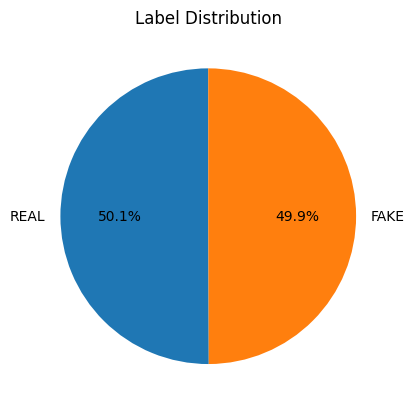

In [ ]:
label_counts = df.value_counts(subset='label')

plt.pie(x=label_counts,
        labels=label_counts.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title("Label Distribution")
plt.show()

- Looks like i have a balanced label distribution. And this will help my model to learn both labels equally with neutral bias. So i will be confident in my model's performance for new datasets if i the model have a good prediciton on the training dataset.

### **Step 2,  Text Preprocessing**

For text preprocessing i will use TF-IDF Vectorization.
 It de-emphasizes common words (like "the" or "is") and highlights unique keywords that might signal "fakeness."

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorization (limiting to 5000 features for efficiency)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X = tfidf.fit_transform(df['title']).toarray()
y = df['label'].values

- I need to prerpocess "label" column into 0 and 1 after spliting the dataset. For this i will use LabelEncoder.

### **Step 3, Split the Dataset**

In [ ]:
from sklearn.model_selection import train_test_split

# Split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [ ]:
!pip install tensorflow

^C


### **Step 4,  Build a Neural Network**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential([
    # Input size is 5000 (from TF-IDF)
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Binary classification (0 or 1)
])

c:\Anacondafiles\envs\GDG_project\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **Step 5,  Train the Model**

In [ ]:
# Step 5: Train
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7551 - loss: 0.5433 - val_accuracy: 0.8066 - val_loss: 0.4166
Epoch 2/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9033 - loss: 0.2432 - val_accuracy: 0.8051 - val_loss: 0.4523
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9657 - loss: 0.1133 - val_accuracy: 0.7972 - val_loss: 0.5560
Epoch 4/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9852 - loss: 0.0517 - val_accuracy: 0.7908 - val_loss: 0.6721
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9945 - loss: 0.0247 - val_accuracy: 0.7893 - val_loss: 0.7655
Epoch 6/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9976 - loss: 0.0131 - val_accuracy: 0.7853 - val_loss: 0.8552
Epoch 7/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9980 - loss: 0.0089 - val_accuracy: 0.7893 - val_loss: 0.9199
Epoch 8/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9986 - loss: 0.0055 - val_accu

- While our trainig accuracy is increasing through the epochs, the validation accuracy is decreasing. The validation accuracy drops after the initial epoch. So i decided to use epoch=5.

In [ ]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.7830 - val_loss: 1.3291
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9992 - loss: 0.0019 - val_accuracy: 0.7814 - val_loss: 1.3330
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9994 - loss: 0.0020 - val_accuracy: 0.7782 - val_loss: 1.4228
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9990 - loss: 0.0028 - val_accuracy: 0.7798 - val_loss: 1.3836
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9992 - loss: 0.0018 - val_accuracy: 0.7774 - val_loss: 1.4256


### **Step 6,  Evaluate the Model**

In [ ]:
# Evaluation on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7774 - loss: 1.4256
Test Loss: 1.4256
Test Accuracy: 0.7774


### **Step 7,  Test Your Model**

In [ ]:
# Manual evaluation
# Example headlines
new_headlines = [
    "Scientists confirm water on Mars.",
    "Secret government project creates invisible humans.",
    "USA and Israel starts a war on Iran",
    "Ethiopian National Football team won the World Cup"
]

# Transforming headlines using the trained TF-IDF vectorizer
X_new = tfidf.transform(new_headlines).toarray()

# Predict probabilities
pred_probs = model.predict(X_new)

# Interpret predictions (threshold 0.5 for binary classification)
pred_labels = (pred_probs > 0.5).astype(int)

for headline, prob, label in zip(new_headlines, pred_probs, pred_labels):
    print(f"Headline: {headline}")
    print(f"Predicted Probability: {prob[0]:.4f}")
    print(f"Predicted Label: {'Real' if label[0] == 1 else 'Fake'}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Headline: Scientists confirm water on Mars.
Predicted Probability: 0.0000
Predicted Label: Fake

Headline: Secret government project creates invisible humans.
Predicted Probability: 0.0000
Predicted Label: Fake

Headline: USA and Israel starts a war on Iran
Predicted Probability: 0.0000
Predicted Label: Fake

Headline: Ethiopian National Football team won the World Cup
Predicted Probability: 0.0008
Predicted Label: Fake



------------------------------------

- I have used a neural network architecture with the suggested architecture:
   - Input → 128 neurons → 64 neurons → Output
- First i used 10 epochs to train the model. However, after seeing the increasing of validation loss, i try to minimize the epoch to 5.
- I have used two activations: ReLu and Sigmoid.
- My model has 99 % accuracy on training data, and 77 % accuracy on new data(validation data).